In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np  
from scipy.signal import butter, filtfilt, iirnotch

: 

In [100]:
filename = "/Users/linhnguyen/Documents/VSCode Workspace/mini project lab/EP1.O1.csv"

df = pd.read_csv(filename, sep = "\t", header = None, nrows = 5000) #Load first 5000 rows

print(df.head())
print(df.info())

       0      1   2    3  4    5  \
0  67635  67635  EP  AF3  6  260   
1  67636  67635  EP   F7  6  260   
2  67637  67635  EP   F3  6  260   
3  67638  67635  EP  FC5  6  260   
4  67639  67635  EP   T7  6  260   

                                                   6  
0  4395.384615,4382.564102,4377.435897,4387.17948...  
1  4489.230769,4475.384615,4474.358974,4486.66666...  
2  4538.461538,4528.717948,4524.615384,4526.15384...  
3  4207.692307,4205.641025,4200.512820,4194.35897...  
4  4497.948717,4498.461538,4494.871794,4497.94871...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       5000 non-null   int64 
 1   1       5000 non-null   int64 
 2   2       5000 non-null   object
 3   3       5000 non-null   object
 4   4       5000 non-null   int64 
 5   5       5000 non-null   int64 
 6   6       5000 non-null   object
dtypes: int64(4), objec

In [101]:
#Label each column
df.columns = ["id", "event", "device", "channel", "code", "size", "data"]
#Drop column because the dataset is default EP (Emotiv Epoc)
df = df.drop("device", axis=1)

print(df.head())
print(df.info())

      id  event channel  code  size  \
0  67635  67635     AF3     6   260   
1  67636  67635      F7     6   260   
2  67637  67635      F3     6   260   
3  67638  67635     FC5     6   260   
4  67639  67635      T7     6   260   

                                                data  
0  4395.384615,4382.564102,4377.435897,4387.17948...  
1  4489.230769,4475.384615,4474.358974,4486.66666...  
2  4538.461538,4528.717948,4524.615384,4526.15384...  
3  4207.692307,4205.641025,4200.512820,4194.35897...  
4  4497.948717,4498.461538,4494.871794,4497.94871...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       5000 non-null   int64 
 1   event    5000 non-null   int64 
 2   channel  5000 non-null   object
 3   code     5000 non-null   int64 
 4   size     5000 non-null   int64 
 5   data     5000 non-null   object
dtypes: int64(4), object(2)
memor

In [102]:
from scipy.interpolate import interp1d

#The fixed length for all signals. As established, 256 samples at 128 Hz gives exactly 2.0 seconds of data.
target_length = 256
fs = 128 # Emotiv EPOC (Sampling Frequency in Hz)
channels_of_interest = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]

#Resamples an array to the target length using linear interpolation
def resample_array(array, target_length):
    current_length = len(array)
    #Efficient check
    if current_length == target_length:
        return array
    #Defining the original grid
    input_indices = np.linspace(0, current_length - 1, current_length)
    #Defining the new grid
    resampled_indices = np.linspace(0, current_length - 1, target_length)
    #Takes X-axis (input_indices) and original Y-axis (array, the signal amplitudes) and defines the line connecting all those points.
    interpolator = interp1d(input_indices, array, kind='linear')
    return np.round(interpolator(resampled_indices), 6)

In [103]:
def parse_and_resample(data_string, target_length):
    try:
        #Convert string to NumPy array
        signal = np.array([float(x) for x in data_string.split(',')])
        #Standardize length to 256
        return resample_array(signal, target_length)
    except ValueError:
        return None 
#Applies the parse_and_resample function to every single row in the existing 'data' column, creating new column named 'processed_signal'.
df['processed_signal'] = df['data'].apply(
    lambda x: parse_and_resample(x, target_length)
)
#Removes any row from the DataFrame where the 'processed_signal' column contains the value None
df.dropna(subset=['processed_signal'], inplace=True)
print(f"Total valid rows remaining: {len(df)}")

Total valid rows remaining: 5000


In [104]:
#Stacking the master matrix for data alignment and rectangularity
all_signals_matrix = np.vstack(df['processed_signal'].tolist())
print(f"Master Signal Matrix Shape: {all_signals_matrix.shape}")
print(all_signals_matrix)

Master Signal Matrix Shape: (5000, 256)
[[4395.384615 4382.48366  4377.741578 ... 4384.808446 4385.624937
  4390.76923 ]
 [4489.230769 4475.368527 4474.745098 ... 4484.888888 4483.101056
  4487.692307]
 [4538.461538 4528.653594 4524.663649 ... 4524.663649 4531.177476
  4531.282051]
 ...
 [4051.794871 4045.641025 4043.589743 ... 4058.461538 4055.897435
  4050.25641 ]
 [4396.410256 4396.361991 4393.478129 ... 4406.924082 4400.609351
  4408.205128]
 [4535.384615 4533.765711 4528.894921 ... 4552.259427 4547.259929
  4546.153846]]


In [105]:
#Calculate global descriptive statistics (across all channels and timepoints)
print("GLOBAL DESCRIPTIVE STATISTICS (All Channels, All Timepoints)")

global_mean = np.mean(all_signals_matrix)
global_std = np.std(all_signals_matrix)
global_min = np.min(all_signals_matrix)
global_max = np.max(all_signals_matrix)
global_median = np.median(all_signals_matrix)
global_range = global_max - global_min

print(f"Overall Mean Amplitude (µV): {global_mean:.4f}")
print(f"Overall Median Amplitude (µV): {global_median:.4f}")
print(f"Overall Standard Deviation (σ): {global_std:.4f}")
print(f"Amplitude Range: {global_range:.4f} µV ({global_min:.4f} to {global_max:.4f})")

GLOBAL DESCRIPTIVE STATISTICS (All Channels, All Timepoints)
Overall Mean Amplitude (µV): 4330.3463
Overall Median Amplitude (µV): 4300.4223
Overall Standard Deviation (σ): 195.0419
Amplitude Range: 1642.0573 µV (3221.6109 to 4863.6682)


In [106]:
#Calculate channel specific statistics
print("CHANNEL-SPECIFIC STATISTICS (Regional Differences)")

#Group the data by channel and calculate descriptive statistics on the signal array
channel_descriptive_stats = df.groupby('channel')['processed_signal'].apply(
    lambda x: pd.Series({
        #Each trial represents 2.0 seconds of brain activity. The analysis uses 256 time points per trial
        'Trial_Count': len(x),
        # Calculate standard deviation across all trials for this channel
        'Mean_Std_Across_Trials': np.std(np.vstack(x.tolist())), 
        # Calculate the median value across all trials for this channel
        'Median_Amplitude': np.median(np.vstack(x.tolist())),
        # Calculate the amplitude range for this channel
        'Amplitude_Range': np.ptp(np.vstack(x.tolist())),
    })
#Convert the Series of Series into a DataFrame
).unstack()

# Sort by Mean_Std_Across_Trials
channel_descriptive_stats = channel_descriptive_stats.sort_values(
    by='Mean_Std_Across_Trials', ascending=False
)

print(channel_descriptive_stats)

CHANNEL-SPECIFIC STATISTICS (Regional Differences)
         Trial_Count  Mean_Std_Across_Trials  Median_Amplitude  \
channel                                                          
F4             357.0              137.123252       4642.696832   
FC5            357.0               68.994394       4266.666666   
F7             358.0               49.644374       4525.660131   
P7             357.0               44.860306       4194.964303   
F8             357.0               43.615018       3988.096532   
T7             357.0               39.501251       4496.146807   
AF3            358.0               37.509565       4384.615384   
AF4            357.0               29.697565       4053.363498   
FC6            357.0               28.980733       4202.745098   
T8             357.0               25.982311       4503.076923   
F3             357.0               25.723702       4529.349421   
O1             357.0               24.702583       4442.592257   
P8             357.0     

In [107]:
def filter_incomplete_events(df, num_expected_channels):
    print(f"Ensuring Event Completeness for All Channels ({num_expected_channels})")
    
    #Count the number of channels present for every unique event ID
    event_counts = df.groupby('event').size()
    
    #Identify the event IDs that have the full complement of channels
    #These are the IDs where the count exactly matches the expected number (14).
    complete_event_ids = event_counts[event_counts == num_expected_channels].index.tolist()
    
    #Filter the original DataFrame to keep only the complete events
    df_complete = df[df['event'].isin(complete_event_ids)].copy()
    
    #Verification and Summary
    new_trial_count = len(complete_event_ids)
    
    print(f"Total rows originally processed: {len(df)}")
    print(f"Total COMPLETE events (trials) found: {new_trial_count}")
    
    if new_trial_count > 0:
        print(f"Final data shape: {new_trial_count * num_expected_channels} rows.")
        
        # Verify the final count for F7 and AF3 (must be the same)
        final_channel_counts = df_complete.groupby('channel').size()
        
        print("\nVerified Final Channel Counts")
        print(f"AF3 Final Count: {final_channel_counts['AF3']}")
        print(f"F7 Final Count: {final_channel_counts['F7']}")
        print(f"Status: Trial counts are now perfectly balanced.")

filter_incomplete_events(df, len(channels_of_interest))

Ensuring Event Completeness for All Channels (14)
Total rows originally processed: 5000
Total COMPLETE events (trials) found: 357
Final data shape: 4998 rows.

Verified Final Channel Counts
AF3 Final Count: 357
F7 Final Count: 357
Status: Trial counts are now perfectly balanced.


In [108]:
#Calculate trial by trial variablity
print("TRIAL-BY-TRIAL VARIABILITY (Noise Assessment)")

# Calculate the standard deviation (variability) for each individual trial
df['trial_std'] = df['processed_signal'].apply(np.std)

# Find the trials with the highest variability (potential artifacts)
most_variable_trials = df.sort_values(by='trial_std', ascending=False).head(5)

print("Top 5 Most Variable Trials (Highest STD - Potential Artifacts):")
print(most_variable_trials[['channel', 'code', 'trial_std', 'event']])

TRIAL-BY-TRIAL VARIABILITY (Noise Assessment)
Top 5 Most Variable Trials (Highest STD - Potential Artifacts):
     channel  code   trial_std  event
1389     FC5     0  359.310924  67734
4640      O1     4  177.270184  67966
2286      T7     0  147.387363  67798
2300      T7     1  128.156007  67799
1417     FC5     2  121.018733  67736


In [109]:
# Define the bandpass window (0.5 Hz to 40 Hz)
low, high = 0.5, 40

#Bandpass filter design: Creates the filter coefficients (b, a)
#Order 4 provides a good balance between steepness and minimal distortion.
#Frequencies are normalized by the Nyquist frequency (fs/2).
b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')

def bandpass(sig):
    #Apply the bandpass filter forward and backward (filtfilt) 
    #to ensure zero-phase distortion.
    return filtfilt(b, a, sig)
    
#Notch filter design (50 Hz power line noise)
#Q = 30 provides a sharp, narrow band rejection to minimize impact on neighboring brain rhythms.
notch_b, notch_a = iirnotch(50, Q=30, fs=fs)

def notch(sig):
    #Apply the Notch filter for power line hum removal.
    return filtfilt(notch_b, notch_a, sig)

In [110]:
#Signal cleaning pipeline
def clean_signal(sig):
    sig = sig - np.mean(sig) #Remove DC Offset: Subtracts the mean to center the signal at 0 µV.
    #This addresses the large, non-neural bias observed in the global statistics (e.g., 4300 µV).
    #Bandpass Filter: Removes slow drift (below 0.5 Hz) and muscle/EMG noise (above 40 Hz).
    sig = bandpass(sig) 
    #Notch Filter: Removes the specific electrical hum frequency (50 Hz).
    sig = notch(sig) 
    return sig

In [111]:
def normalize(sig):
    #Z-Score Normalization: Centers the signal at 0 (mean) and scales variance to 1.
    #This is essential for deep learning models to treat features equally.
    #1e-8 is added to the standard deviation to prevent division by zero for flat signals.
    return (sig - np.mean(sig)) / (np.std(sig) + 1e-8)

In [112]:
#Data processing execution
# List to store the final cleaned, normalized signal arrays
processed = []
# List to store the corresponding digit code labels
labels = []

# Iterate over a sample of the DataFrame 
for _, row in df.head(5000).iterrows(): #Try on 5000 samples (since 5000 is loaded)
    #Parse data
    sig = np.array([float(x) for x in row["data"].split(",")])
    #Fulling cleaning chain
    sig = clean_signal(sig)
    #Z-Score normalization
    sig = normalize(sig)
    #Store final processed signals and its label
    processed.append(sig)
    labels.append(row["code"])

In [113]:
#Confirm the preprocessing execution
#Choose trial sample index
sample_index = 0
try:
    #Access raw data string
    raw_data_string = df.iloc[sample_index]["data"]
    
    #Parse and resample
    signal_raw = np.array([float(x) for x in raw_data_string.split(",")])
    signal_raw = resample_array(signal_raw, target_length)
     
    #Apply the full cleaning chain to the raw signal
    #Use .copy() to ensure the original signal_raw remains unchanged for comparison
    cleaned_signal = clean_signal(signal_raw.copy())

except NameError:
    print("ERROR: Necessary functions (clean_signal/resample_array) or DataFrame (df) are not defined.")
    exit()
except Exception as e:
    print(f"An error occurred during data extraction/cleaning: {e}")
    exit()

print("NUMERICAL CONFIRMATION OF PREPROCESSING (BEFORE PLOTTING)")
print(f"Analysis performed on Sample Trial Index: {sample_index}\n")

#DC Offset Removal (Mean Amplitude)
raw_mean = np.mean(signal_raw)
cleaned_mean = np.mean(cleaned_signal)

print(f"1. DC OFFSET REMOVAL (Mean Amplitude):")
print(f"   Raw Signal Mean:     {raw_mean:.4f} µV")
print(f"   Cleaned Signal Mean: {cleaned_mean:.4f} µV (Goal is near 0)")

#Noise Reduction (Standard Deviation)
raw_std = np.std(signal_raw)
cleaned_std = np.std(cleaned_signal)

print(f"2. NOISE REDUCTION (Standard Deviation):")
print(f"   Raw Signal STD (Noise):    {raw_std:.4f} µV")
print(f"   Cleaned Signal STD (Noise):{cleaned_std:.4f} µV")
print(f"   Reduction Percentage:      {100 * (raw_std - cleaned_std) / raw_std:.2f}%")

#Total Signal Magnitude Check (Peak-to-Peak Range)
raw_range = np.ptp(signal_raw)
cleaned_range = np.ptp(cleaned_signal)

print(f"3. AMPLITUDE RANGE CHECK:")
print(f"   Raw Signal Peak-to-Peak:   {raw_range:.4f} µV")
print(f"   Cleaned Signal Peak-to-Peak:{cleaned_range:.4f} µV")

NUMERICAL CONFIRMATION OF PREPROCESSING (BEFORE PLOTTING)
Analysis performed on Sample Trial Index: 0

1. DC OFFSET REMOVAL (Mean Amplitude):
   Raw Signal Mean:     4382.7613 µV
   Cleaned Signal Mean: -0.2492 µV (Goal is near 0)
2. NOISE REDUCTION (Standard Deviation):
   Raw Signal STD (Noise):    8.1805 µV
   Cleaned Signal STD (Noise):6.6626 µV
   Reduction Percentage:      18.55%
3. AMPLITUDE RANGE CHECK:
   Raw Signal Peak-to-Peak:   37.1986 µV
   Cleaned Signal Peak-to-Peak:35.6769 µV


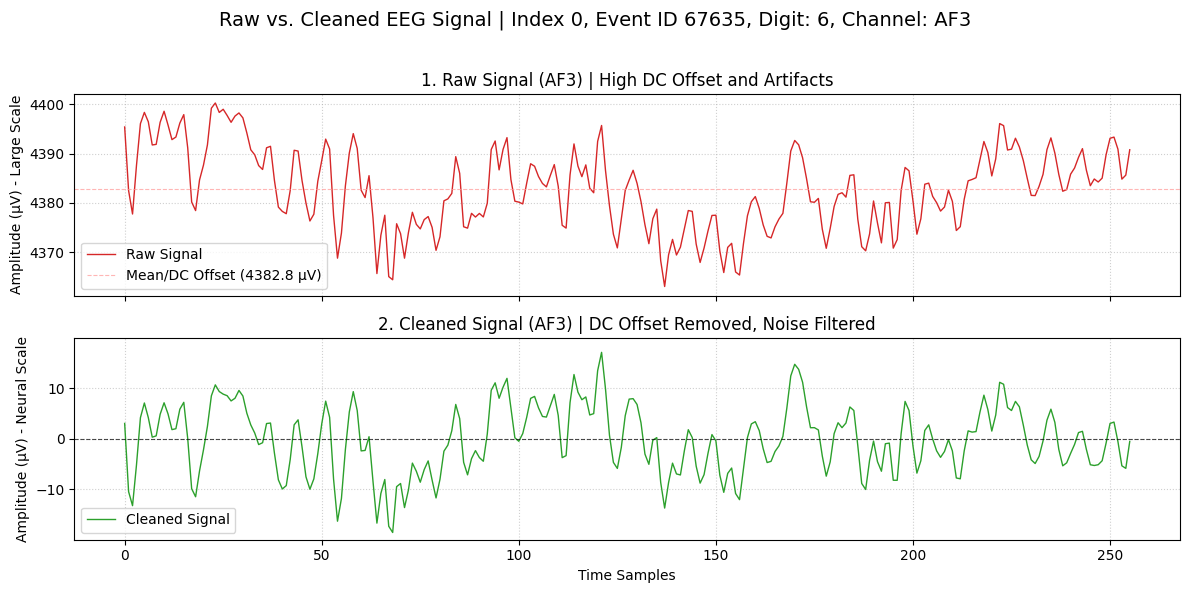

In [114]:
#Get the row corresponding to the sample index
selected_row = df.iloc[sample_index]
channel_name = selected_row["channel"] 
event_id = selected_row["event"]
digit_code = selected_row["code"]

#Load and process signal for plotting
raw_data_string = selected_row["data"]
signal = np.array([float(x) for x in raw_data_string.split(",")])
signal = resample_array(signal, target_length)
cleaned_signal = clean_signal(signal.copy())

#Plotting code 
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle(f"Raw vs. Cleaned EEG Signal | Index {sample_index}, Event ID {event_id}, Digit: {digit_code}, Channel: {channel_name}", fontsize=14)

#Raw Signal (Highlighting DC Offset and Noise Scale)
axes[0].plot(signal, label="Raw Signal", color="#D62728", linewidth=1)

#Calculate the DC offset line (the mean) to emphasize the bias
raw_mean = np.mean(signal)
axes[0].axhline(raw_mean, color='#FF9896', linestyle='--', label=f'Mean/DC Offset ({raw_mean:.1f} µV)',linewidth=0.8, alpha=0.7)

axes[0].set_title(f"1. Raw Signal ({channel_name}) | High DC Offset and Artifacts")
axes[0].set_ylabel("Amplitude (µV) - Large Scale")
axes[0].legend(loc='lower left')
axes[0].grid(True, linestyle=':', alpha=0.6)

#Cleaned Signal (Highlighting Centered and Reduced Noise)
axes[1].plot(cleaned_signal, label="Cleaned Signal", color="#2CA02C", linewidth=1)

# Add the final mean line to confirm centering at 0
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

axes[1].set_title(f"2. Cleaned Signal ({channel_name}) | DC Offset Removed, Noise Filtered")
axes[1].set_ylabel("Amplitude (µV) - Neural Scale")
plt.xlabel(f"Time Samples")

#Adjust Y-axis limits to focus only on the neural activity scale
current_std = np.std(clean_signal(signal))
axes[1].set_ylim(-3 * current_std, 3 * current_std) # Set limits relative to the clean signal's STD
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

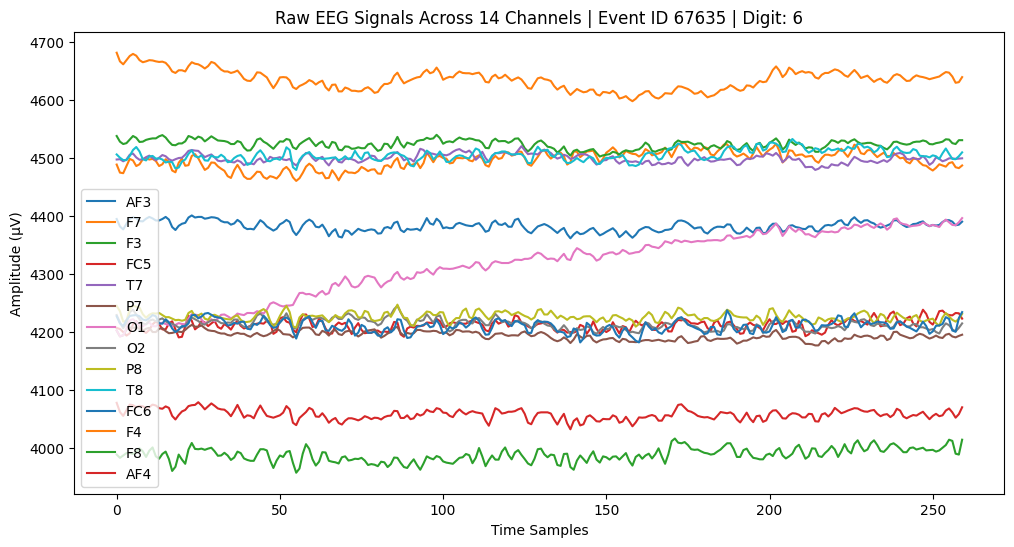

In [115]:
import matplotlib.pyplot as plt

subset = df[df["event"] == event_id]

plt.figure(figsize=(12,6))
for _, row in subset.iterrows():
    signal = np.array([float(x) for x in row["data"].split(",")])
    plt.plot(signal, label=row["channel"])

plt.title(f"Raw EEG Signals Across 14 Channels | Event ID {event_id} | Digit: {digit_code}")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.show()

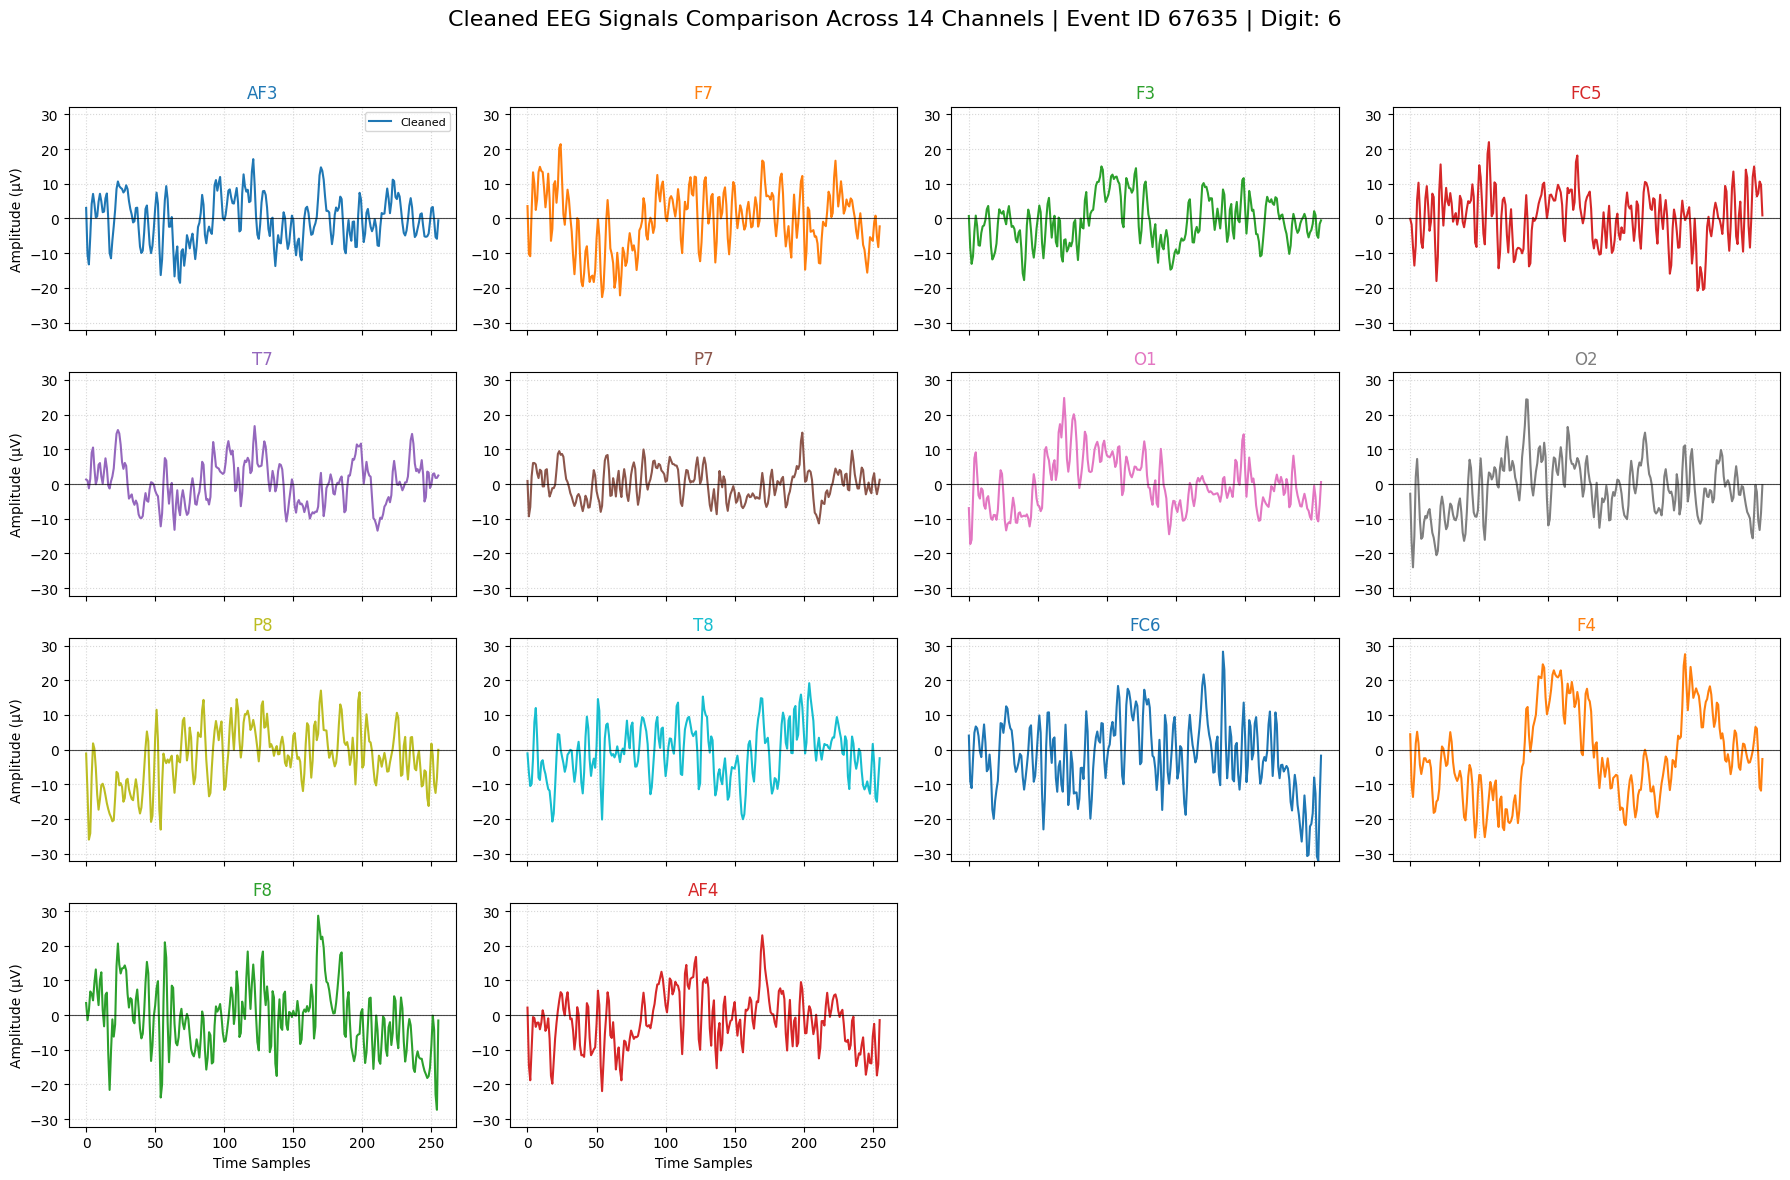

In [116]:
#Isolate the full event subset (all 14 channels)
event_subset = df[df["event"] == event_id].copy()
channels = event_subset['channel'].unique()
num_channels = len(channels)

#Get the color palette (assuming it's defined elsewhere)
COLOR_CYCLE = plt.cm.tab10.colors 
COLOR_LIST = [COLOR_CYCLE[i % len(COLOR_CYCLE)] for i in range(16)]

#Set up the 4x4 plotting grid
fig_spatial, axes_spatial = plt.subplots(4, 4, figsize=(18, 12), sharex=True)
axes_spatial = axes_spatial.flatten()
time_axis = np.arange(target_length)


#Determine Global Y-Limits for Cleaned Signals
all_clean_stds = []
processed_signals = {}
for _, row in event_subset.iterrows():
    # Process signal once to determine its clean STD
    raw_sig = np.array([float(x) for x in row["data"].split(",")])
    raw_sig_resampled = resample_array(raw_sig, target_length) 
    cleaned_sig = clean_signal(raw_sig_resampled.copy())
    
    #Store processed signal for plotting
    processed_signals[row['channel']] = cleaned_sig
    all_clean_stds.append(np.std(cleaned_sig))

#Set consistent clean Y-limit (4 times the mean STD of all channels)
global_clean_std = np.mean(all_clean_stds)
y_limit_clean = 4 * global_clean_std

fig_spatial.suptitle(
    f"Cleaned EEG Signals Comparison Across {num_channels} Channels | Event ID {event_id} | Digit: {digit_code}", 
    fontsize=16
)

#Iterate and Plot (Two lines per subplot)
for i, current_channel in enumerate(channels):
    ax = axes_spatial[i]
    current_color = COLOR_LIST[i]
    row = event_subset[event_subset['channel'] == current_channel].iloc[0]
    
    #Reprocess the raw and clean signal for plotting 
    raw_sig = np.array([float(x) for x in row["data"].split(",")])
    raw_sig_resampled = resample_array(raw_sig, target_length) 

    #Plotting cleaned signal 
    ax.plot(time_axis, processed_signals[current_channel], label="Cleaned", color=current_color, linewidth=1.5)
    
    #Annotate and Style
    ax.set_title(f"{current_channel}", fontsize=12, color=current_color)
    ax.axhline(raw_mean, color='r', linestyle=':', linewidth=0.5, alpha=0.5) #DC offset line
    ax.axhline(0, color='k', linestyle='-', linewidth=0.8, alpha=0.7) #Zero line
    
    ax.set_ylim(-y_limit_clean, y_limit_clean) #Set clean Y-limit
    ax.grid(True, linestyle=':', alpha=0.5)
    
    #Final Axis Labels
    if i == 0:
        ax.legend(loc='upper right', fontsize=8) #Only show legend once

#Final Layout Adjustments
for i in range(16):
    ax = axes_spatial[i]
    if i < num_channels:
        if i >= 12: 
            ax.set_xlabel("Time Samples") 
            
        if i % 4 == 0:
            ax.set_ylabel("Amplitude (µV)")
            
    else:
        fig_spatial.delaxes(ax)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

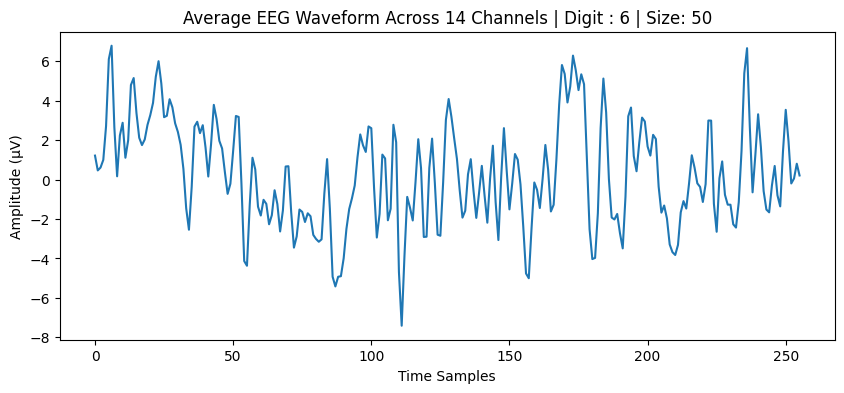

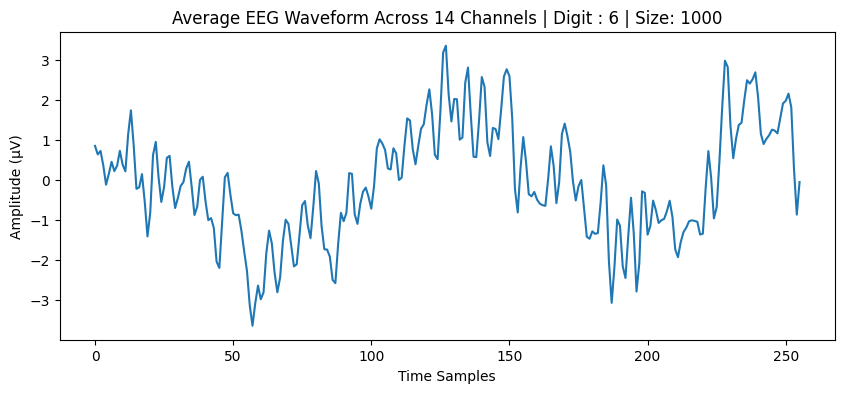

In [117]:
def plot_digit_erp(df, digit, sample_size):
    #Isolates all rows (signals) that correspond to the target digit code (e.g., code 6).
    subset = df[df["code"] == digit].head(sample_size).copy()
    
    if subset.empty:
        print(f"Error: No trials found for digit {digit}. Load more data to find the digit.")
        return

    signals = []
    signal_lengths = []
    
    #Extract, parse, clean signals
    for i, row in subset.iterrows():
        try:
            sig = np.array([float(x) for x in row["data"].split(",")])
            sig = resample_array(sig, target_length)
            sig = clean_signal(sig)
            signals.append(sig)
            signal_lengths.append(len(sig))
        except ValueError as e:
            print(f"Skipping row {i} due to non-numeric data in 'data' column: {e}")
            continue
            
    #Plotting
    if signals:
        avg_signal = np.mean(signals, axis=0)
        plt.figure(figsize=(10,4))
        plt.plot(avg_signal)
        plt.title(f"Average EEG Waveform Across 14 Channels | Digit : {digit} | Size: {sample_size}")
        plt.xlabel("Time Samples")
        plt.ylabel("Amplitude (µV)")
        plt.show()
    else:
        print("Cannot plot: 'signals' list is empty or filtering removed all elements.")
            
plot_digit_erp(df, 6, 50)
plot_digit_erp(df, 6, 1000)